In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv("Real estate.csv")

In [11]:
data.drop(["No","X1 transaction date","X5 latitude","X6 longitude"],axis=1,inplace=True)

Step1: Load the dataset
Step2: Problem identification (Regression / Classification etc...)
Step3: Dependency or correlation by number or by graph
Step4: Select Algorithm
Step5: Split Data into Training and Testing Data set
Step6: Fit the Model on Training Data (Train the model)
Step7: Performance Evaluation on Train Data
Step8: Predict the model on test data set
Step9: Performance Evaluation on Test Data
Step10: Save and Deploy

In [12]:
data

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,Y house price of unit area
0,32.0,84.87882,10,37.9
1,19.5,306.59470,9,42.2
2,13.3,561.98450,5,47.3
3,13.3,561.98450,5,54.8
4,5.0,390.56840,5,43.1
...,...,...,...,...
409,13.7,4082.01500,0,15.4
410,5.6,90.45606,9,50.0
411,18.8,390.96960,7,40.6
412,8.1,104.81010,5,52.5


In [13]:
data.isna().sum()

X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
Y house price of unit area                0
dtype: int64

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 4 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X2 house age                            414 non-null    float64
 1   X3 distance to the nearest MRT station  414 non-null    float64
 2   X4 number of convenience stores         414 non-null    int64  
 3   Y house price of unit area              414 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 13.1 KB


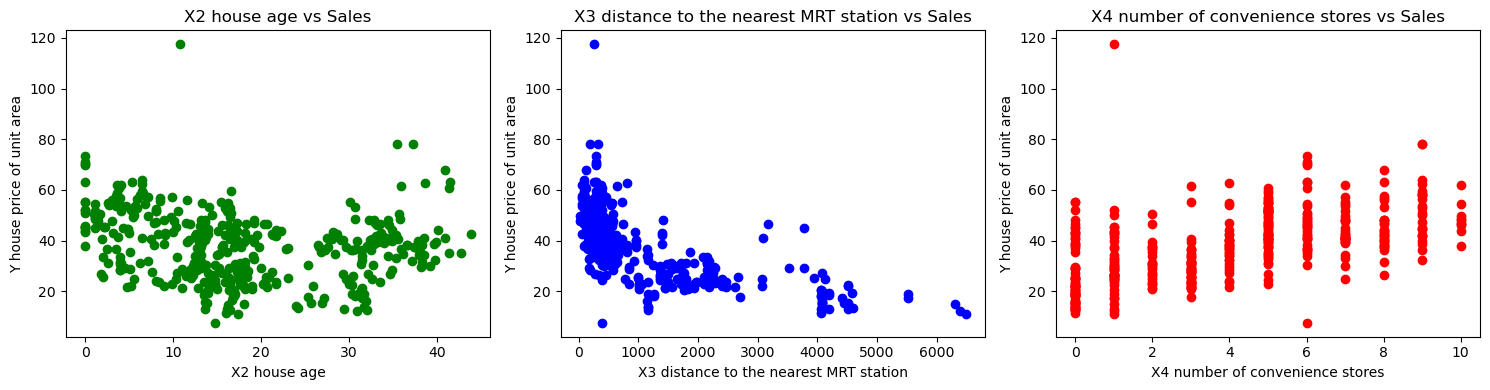

In [15]:
import matplotlib.pyplot as plt

features = ["X2 house age", "X3 distance to the nearest MRT station", "X4 number of convenience stores"]
colors = ["green", "blue", "red"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feature in enumerate(features):
    axes[i].scatter(data[feature], data["Y house price of unit area"], color=colors[i])
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Y house price of unit area")
    axes[i].set_title(f"{feature} vs Sales")

plt.tight_layout()
plt.show()

In [17]:
data.corr()

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,Y house price of unit area
X2 house age,1.000000,0.025622,0.049593,-0.210567
X3 distance to the nearest MRT station,0.025622,1.000000,-0.602519,-0.673613
X4 number of convenience stores,0.049593,-0.602519,1.000000,0.571005
Y house price of unit area,-0.210567,-0.673613,0.571005,1.000000


In [22]:
x = data.drop(["Y house price of unit area"],axis=1)
y = data[["Y house price of unit area"]]

In [23]:
x

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores
0,32.0,84.87882,10
1,19.5,306.59470,9
2,13.3,561.98450,5
3,13.3,561.98450,5
4,5.0,390.56840,5
...,...,...,...
409,13.7,4082.01500,0
410,5.6,90.45606,9
411,18.8,390.96960,7
412,8.1,104.81010,5


In [24]:
y

,Y house price of unit area
0,37.9
1,42.2
2,47.3
3,54.8
4,43.1
...,...
409,15.4
410,50.0
411,40.6
412,52.5


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.20,random_state=42)

In [30]:
y_test.shape

(83, 1)

In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
mlr = LinearRegression()

In [33]:
mlr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
mlr.coef_

array([[-0.25840543, -0.00549834,  1.24734248]])

In [35]:
mlr.intercept_

array([43.51488014])

In [36]:
y_train_pred = mlr.predict(x_train)

In [37]:
y_train_pred

array([[40.61147319],
       [34.24931066],
       [33.46316522],
       [41.34828455],
       [44.29670196],
       [33.18197305],
       [43.2885347 ],
       [19.89611353],
       [40.17195685],
       [38.98167906],
       [43.22481609],
       [47.10242815],
       [39.78156537],
       [32.54866438],
       [44.18782394],
       [30.51341754],
       [44.89916013],
       [30.4904674 ],
       [36.36814755],
       [45.01225253],
       [33.05605551],
       [50.87630039],
       [52.79653352],
       [32.49470109],
       [27.79439112],
       [40.22363794],
       [36.12613257],
       [34.63786239],
       [40.54504643],
       [44.92762325],
       [45.43582024],
       [23.91900857],
       [42.49532436],
       [43.97461726],
       [44.79554143],
       [32.10636074],
       [34.10532334],
       [43.15953967],
       [18.49004561],
       [49.38793224],
       [49.67613537],
       [38.52614924],
       [44.17196729],
       [18.84794022],
       [51.73010247],
       [14

In [38]:
from sklearn.metrics import r2_score,root_mean_squared_error

In [39]:
root_mean_squared_error(y_train,y_train_pred)

9.554628506272044

In [40]:
r2_score(y_train,y_train_pred)

0.5146436173066767

In [41]:
y_test_predict = mlr.predict(x_test)

In [42]:
root_mean_squared_error(y_test,y_test_predict)

7.673868078735504

In [43]:
r2_score(y_test,y_test_predict)

0.6489726933106557

In [46]:
def predict_price(house_age,distance_MRT_station,convenience_stores):
    inp = np.array([[house_age,distance_MRT_station,convenience_stores]])
    return mlr.predict(inp)

In [47]:
house_age = float(input("Enter house age:"))
mrt_station = float(input("Enter MRT Station distance:"))
convenience_stores = int(input("Enter Convenience Stores near house:"))
predict_price(house_age,mrt_station,convenience_stores)

Enter house age: 32.0
Enter MRT Station distance: 84.87882
Enter Convenience Stores near house: 10


C:\Users\hp\Downloads\apps\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[47.25263832]])

In [44]:
data

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,Y house price of unit area
0,32.0,84.87882,10,37.9
1,19.5,306.59470,9,42.2
2,13.3,561.98450,5,47.3
3,13.3,561.98450,5,54.8
4,5.0,390.56840,5,43.1
...,...,...,...,...
409,13.7,4082.01500,0,15.4
410,5.6,90.45606,9,50.0
411,18.8,390.96960,7,40.6
412,8.1,104.81010,5,52.5
